In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [3]:
username="postgres"
password="Roshan123"
host="localhost"
port="5432"
database="customer_churn_db"

engine=create_engine(
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

df=pd.read_sql(
    "SELECT * FROM customer_data",
    engine
)

print(df.shape)

df.head()

(7043, 25)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customer_lifetime_value,engagement_score,ticket_frequency,days_since_last_login
0,0.763277,0.0,0.0,1.0,0.0,0.013889,0.0,0.5,0.0,0.0,...,0.0,1.0,0.666667,0.115423,0.383614,0.0,0.013889,0.115423,0.0,0.0
1,0.562624,1.0,0.0,0.0,0.0,0.472222,1.0,0.0,0.0,1.0,...,0.5,0.0,1.000000,0.385075,0.224502,0.0,0.472222,0.385075,0.0,0.0
2,0.364101,1.0,0.0,0.0,0.0,0.027778,1.0,0.0,0.0,1.0,...,0.0,1.0,1.000000,0.354229,0.024043,1.0,0.027778,0.354229,0.0,0.0
3,0.785998,1.0,0.0,0.0,0.0,0.625000,0.0,0.5,0.0,1.0,...,0.5,0.0,0.000000,0.239303,0.214395,0.0,0.625000,0.239303,0.0,0.0
4,0.924595,0.0,0.0,0.0,0.0,0.027778,1.0,0.0,0.5,0.0,...,0.0,1.0,0.666667,0.521891,0.141654,1.0,0.027778,0.521891,0.0,0.0


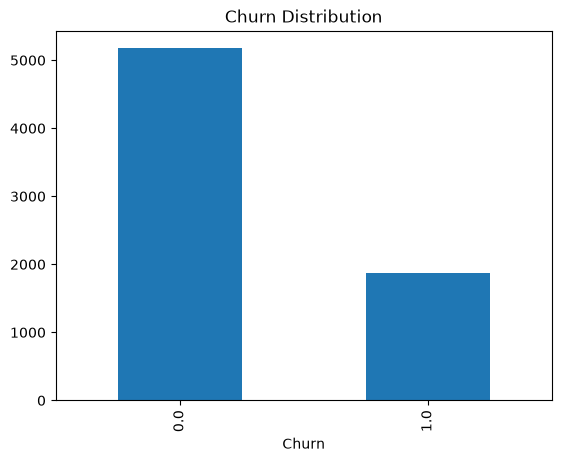

In [4]:
df["Churn"].value_counts().plot(
    kind="bar"
)

plt.title("Churn Distribution")

plt.show()

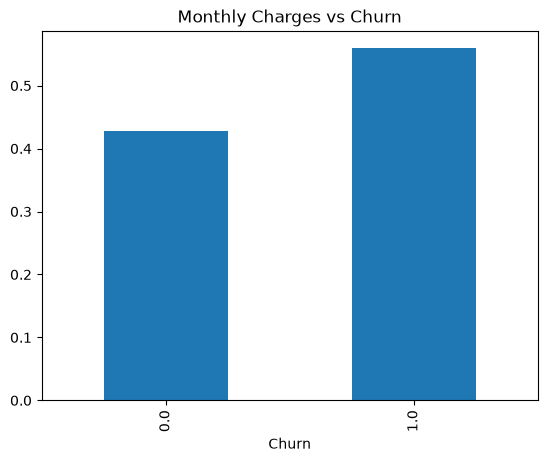

In [5]:
df.groupby("Churn")["MonthlyCharges"].mean().plot(
    kind="bar"
)

plt.title("Monthly Charges vs Churn")

plt.show()

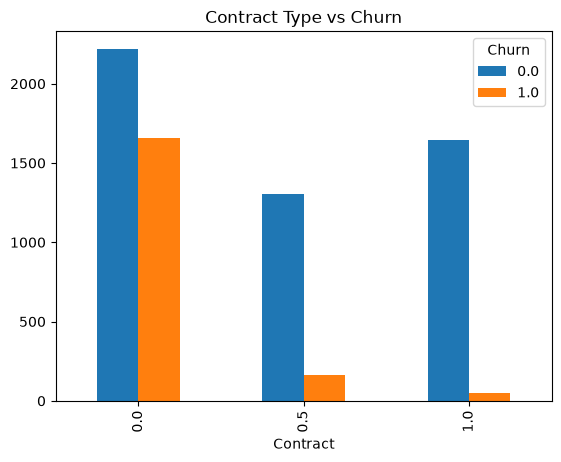

In [6]:
pd.crosstab(
    df["Contract"],
    df["Churn"]
).plot(
    kind="bar"
)

plt.title("Contract Type vs Churn")

plt.show()

In [7]:
if "Location" in df.columns:

    pd.crosstab(
        df["Location"],
        df["Churn"]
    ).head(10).plot(
        kind="bar"
    )

    plt.title("Geography vs Churn")

    plt.show()

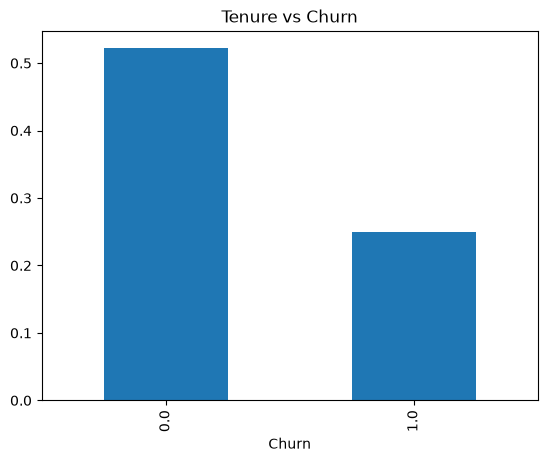

In [8]:
df.groupby("Churn")["tenure"].mean().plot(
    kind="bar"
)

plt.title("Tenure vs Churn")

plt.show()

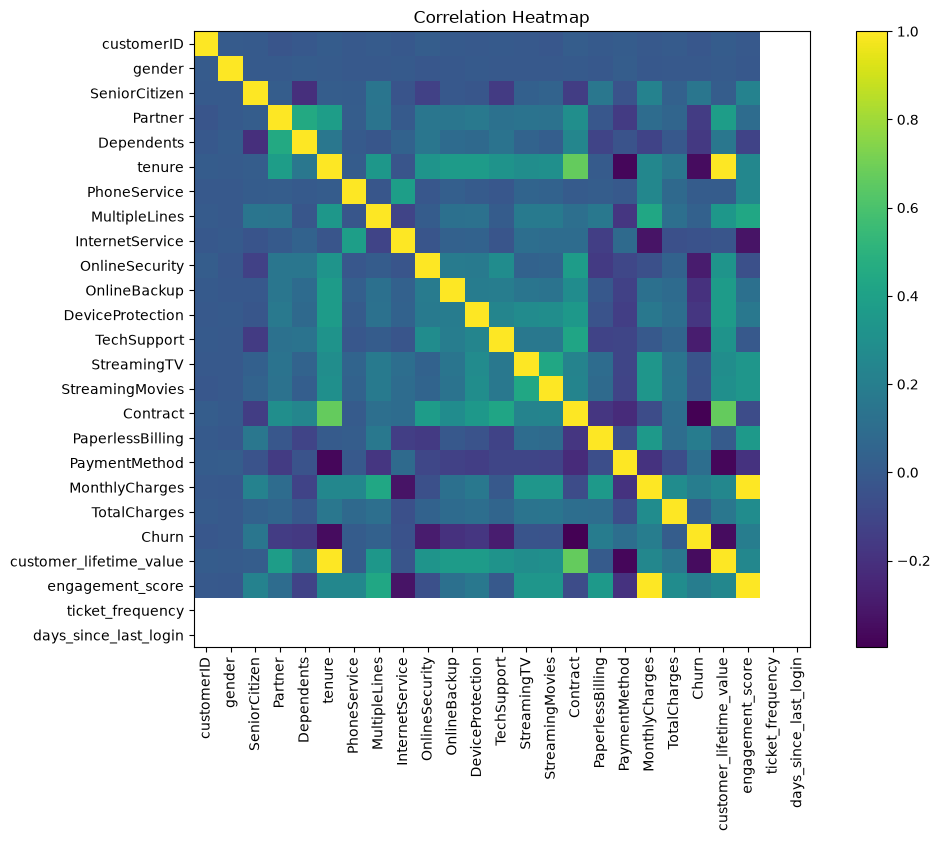

In [9]:
import numpy as np

corr=df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Heatmap")

plt.show()